# ELEN90088 System Optimisation and Machine Learning, 2026

# Exercise 2
## Due date: <u> 23:59, Sunday the 10th May, 2026 </u>




## Submission guidline:

* Answer the exercise questions in this Python notebook itself.
* One submission per group by the due date on LMS. Export your notebook file (.ipynb) as a PDF file. You should submit both ipynb and pdf files.
* For questions involving mathematical derivation, you can either choose to type your solutions using Markdown (Latex), or attach a photo of your hand-written solution in the file.

<br>

## Grading:

## Exercise 2 self grading due date: <u> 23:59, Monday the 18th May, 2026 </u>
### Option 1:
*  By default, you will grade your homeworks with the solution provided by us
* Submission of graded homeworks: solutions will be posted on LMS on 11th May with a grading guideline. You have one week to grade your homeworks. Submit your graded homework (as a PDF file) before 23:59, 18th May. You should note down all marks for individual subquestions, and include your total mark on page 1 of your PDF file. An example will be provided later.
* If you do not submit a graded version by 23:59, 18th May, your homework will be graded by demonstrators.

### Option 2:
* If you wish to have your homeworks graded by demonstrators, please send an email to Muhan (muhan.guan.1@unimelb.edu.au) by the homework due date, and you do not need to submit a graded version. If you choose this path and submit a graded version, we will still mark your homework instead of using your self-graded results.





## Submission guideline:

* One submission per group by the due date on LMS.
* Answer the exercise questions in this Python notebook itself.
* Export your notebook file (.ipynb) as a PDF file, on which we give marks and comments. This means that each group should submit two versions of the exercise report (.ipynb file and PDF).
* Demonstrators will conduct a brief oral assessment for selected groups in subsequent workshop. Details will be announced on LMS.
* Regarding the use of LLM and other generative AI tools: refer to information in the introductory slides.





## Question 1 (Bayesian infrence, MLE and MAP) (Mark:  5 + 7 + 2 + 6 = 20 points)
In this question, we'll explore Bayesian infrence, MLE and MAP.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
plt.rcParams["animation.html"] = "jshtml"
from scipy.stats import bernoulli, beta

**A lucky find**

On the way to class, you discover an unusual coin on the ground.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/68/1_2_penny_Middlesex_DukeYork_1795_1ar85_%288737903267%29.jpg" alt="Coin" width="350"/>

As a dedicated student in SOML, you're interested in determining whether the coin is _biased_.
More specifically, you want to estimate the probability $\theta$ that the coin will land heads-up when you toss it. If $\theta \approx \frac{1}{2}$ then we say that the coin is _unbiased_ (or fair).

You can use the function below to simulate a coin toss: it returns `1` for heads and `0` for tails.

In [48]:
def toss_coin():
    if bernoulli.rvs(p = (int.from_bytes("coin".encode(), 'little') % 10000)/10000):
        return 1
    return 0

In [49]:
(int.from_bytes("coin".encode(), 'little') % 10000)/10000

0.3555

In [50]:
x1 = toss_coin()
print(x1)

0


**Prior belief**

Before you even toss the coin, you notice that the heads side appears to have more mass.
Thus, your _prior belief_ is that $\theta$ is slightly biased away from $\frac{1}{2}$ towards 0—i.e. you expect tails are more likely.

To quantify this prior belief, we assume that the prior distribution for $\theta$ is $\mathrm{Beta}(a,b)$, for some choice of the hyperparameters $a, b > 0$.
(See [link](https://en.wikipedia.org/wiki/Beta_distribution) for info about the Beta distribution.)
The prior probability density function for $\theta$ is therefore given by:

$$ p(\theta) = \frac{1}{B(a,b)} \theta^{a-1} (1 - \theta)^{b-1} $$

where $B(a,b)$ is a special function called the _Beta function_.

Select appropriate values for $a$ and $b$ by looking at the plot of $p(\theta)$ below.

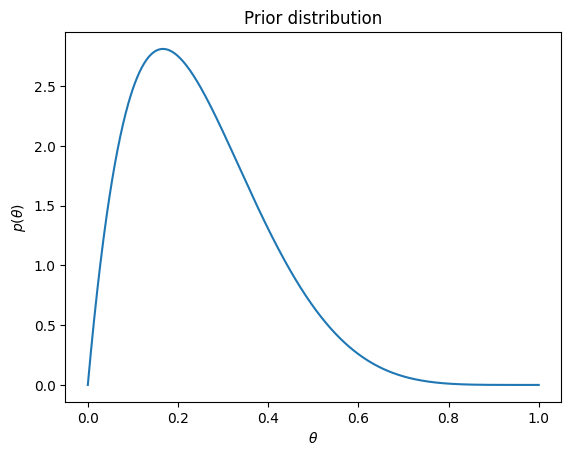

In [51]:
a = 2 # fill in
b = 6 # fill in
theta = np.linspace(0, 1, 1001)
plt.plot(theta, beta.pdf(theta, a, b))
plt.title('Prior distribution')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$p(\theta)$')
plt.show()

**Posterior updates:** Now toss the coin once and denote the outcome by $x_1$.

In [52]:
x1 = toss_coin()
print(x1)

0


We can update our belief about $\theta$, based on this new evidence $x_1$.
To do this we apply Bayes' rule to compute the posterior for $\theta$:

$$ p(\theta | x_1) = \frac{p(x_1 | \theta) \, p(\theta)}{p(x_1)} \propto p(x_1 | \theta) \, p(\theta)$$

where $p(\theta)$ is the prior given above and

$$ p(x_1 | \theta) = \theta^{x_1} (1 - \theta)^{1 - x_1} $$

is the likelihood.

\[Note: We always assume the tosses are independent, otherwise the likelihood for $x_2$ would depend on $x_1$.\]
***


### Part A: Mathematical Derivation

Toss the coin a second time, denoting the outcome by $x_2$.

In [53]:
x2 = toss_coin()
print(x2)

1


Again, we want to update our belief about $\theta$ based on the new information $x_2$.
We take the previous posterior $p(\theta|x_1)$ as the new prior and apply Bayes' rule:

$$ p(\theta | x_1, x_2) \propto p(x_2 | \theta) p(\theta | x_1)$$



***
Show that for $n$ coin tosses, the posterior is $\theta | x_1, \ldots, x_n \sim \operatorname{Beta}[n_H + a, n - n_H + b]$ where $n_H = \sum_{i = 1}^{n} x_i$ is the number of heads observed.

***

**Solution (Part A):**

We prove by induction that
$$p(\theta\mid x_1,\ldots,x_n)=\operatorname{Beta}(\theta;\,n_H+a,\,n-n_H+b),$$
where $n_H=\sum_{i=1}^n x_i$.

**Base case ($n=0$):** the prior is $\operatorname{Beta}(\theta;a,b)$, which matches the formula with $n_H=0$.

**Inductive step:** assume $p(\theta\mid x_1,\ldots,x_{n-1})=\operatorname{Beta}(\theta;\,n_{H,n-1}+a,\,(n-1)-n_{H,n-1}+b)$, i.e.
$$p(\theta\mid x_1,\ldots,x_{n-1})\propto \theta^{n_{H,n-1}+a-1}(1-\theta)^{(n-1)-n_{H,n-1}+b-1}.$$
Bernoulli likelihood for the $n$-th toss is $p(x_n\mid\theta)=\theta^{x_n}(1-\theta)^{1-x_n}$. By Bayes' rule,
$$
p(\theta\mid x_1,\ldots,x_n)\propto p(x_n\mid\theta)\,p(\theta\mid x_1,\ldots,x_{n-1})\propto \theta^{n_{H,n-1}+x_n+a-1}(1-\theta)^{(n-1)-n_{H,n-1}+(1-x_n)+b-1}.
$$
Since $n_{H,n-1}+x_n=n_H$ and $(n-1)-n_{H,n-1}+(1-x_n)=n-n_H$, we obtain
$$p(\theta\mid x_1,\ldots,x_n)\propto \theta^{n_H+a-1}(1-\theta)^{n-n_H+b-1},$$
which is $\operatorname{Beta}(n_H+a,\,n-n_H+b)$. $\blacksquare$


### Part B:  Mathematical Derivation for MAP estimator and MLE estimator

The posterior $\theta|x_1, \ldots, x_n$ contains all the information we know about $\theta$ after observing $n$ coin tosses.
One way of obtaining a point estimate of $\theta$ from the posterior, is to take the value with the maximum a posteriori probability (MAP):
$$
\begin{align}
    \hat{\theta}_\mathrm{MAP} &= \arg \max_{\theta} p(\theta|x_1, \ldots, x_n) \tag{1}
\end{align}
$$

In general, the MAP estimator gives a different result to the maximum likelihood estimator (MLE) for $\theta$:
$$
\begin{align}
    \hat{\theta}_\mathrm{MLE} &=\arg \max_{\theta} p(x_1, \ldots, x_n|\theta) \tag{2}\\
\end{align}
$$

***
 How would you derive the above results for $\hat{\theta}_\mathrm{MAP}$ and  $\hat{\theta}_\mathrm{MLE}$? Setup the equations for solving $\hat{\theta}_\mathrm{MAP}$ and  $\hat{\theta}_\mathrm{MLE}$ and then solve them.


**Solution (Part B):**

**MLE.** The likelihood is $p(x_1,\ldots,x_n\mid\theta)=\theta^{n_H}(1-\theta)^{n-n_H}$. Take the log-likelihood
$$\ell(\theta)=n_H\log\theta+(n-n_H)\log(1-\theta).$$
Set $\dfrac{d\ell}{d\theta}=\dfrac{n_H}{\theta}-\dfrac{n-n_H}{1-\theta}=0\;\Rightarrow\; n_H(1-\theta)=(n-n_H)\theta\;\Rightarrow\;\boxed{\hat\theta_{\mathrm{MLE}}=\dfrac{n_H}{n}}.$$
The second derivative is negative, so this is a maximum.

**MAP.** The posterior is $\operatorname{Beta}(n_H+a,\,n-n_H+b)$, so
$$\log p(\theta\mid x_{1:n})=\text{const}+(n_H+a-1)\log\theta+(n-n_H+b-1)\log(1-\theta).$$
Setting the derivative to zero:
$$\frac{n_H+a-1}{\theta}-\frac{n-n_H+b-1}{1-\theta}=0\;\Rightarrow\;\boxed{\hat\theta_{\mathrm{MAP}}=\dfrac{n_H+a-1}{n+a+b-2}}\quad(\text{valid when }a,b\ge 1).$$

So the MAP estimator is the MLE smoothed by pseudo-counts $(a-1)$ heads and $(b-1)$ tails coming from the prior. As $n\to\infty$ the MAP and MLE coincide.


### Part C: Programming
Let's now toss the coin an additional 100 times (so that $n = 102$) using the given function ``toss_coin()``. After each toss, compute and record $\hat{\theta}_\mathrm{MLE}$ and $\hat{\theta}_\mathrm{MAP}$ (using the expresssion you solved from Part B). Plot both estimates them as two lines on the same graph. To compute $\hat{\theta}_\mathrm{MAP}$, we set the parameters of the beta prior distribution as $a=2$ and $b=6$.

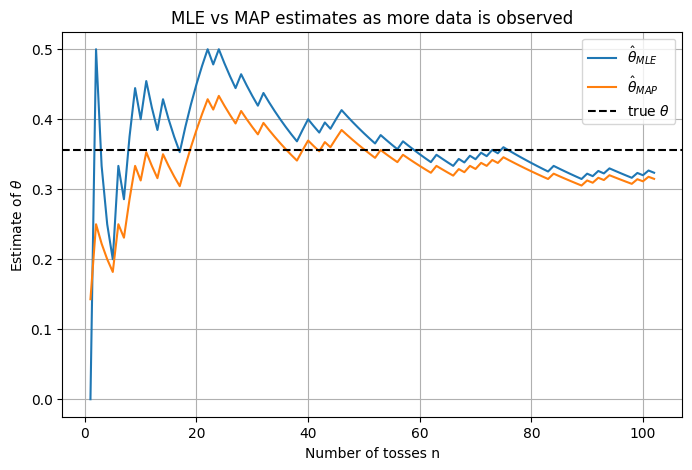

Final MLE  = 0.3235
Final MAP  = 0.3148


In [54]:
# Part C: Track MLE and MAP estimates over additional 100 tosses (so n = 102)
np.random.seed(0)

a, b = 2, 6  # prior hyperparameters

# Reuse the first two tosses x1 and x2 (already drawn earlier in the notebook).
# We keep things self-contained here by simulating 102 tosses fresh.
tosses = [toss_coin() for _ in range(102)]

theta_mle = []
theta_map = []
n_H = 0
for n_idx, x in enumerate(tosses, start=1):
    n_H += x
    theta_mle.append(n_H / n_idx)
    # MAP only valid when a,b >= 1 (true here)
    theta_map.append((n_H + a - 1) / (n_idx + a + b - 2))

plt.figure(figsize=(8, 5))
plt.plot(range(1, 103), theta_mle, label=r'$\hat\theta_{MLE}$')
plt.plot(range(1, 103), theta_map, label=r'$\hat\theta_{MAP}$')
plt.axhline((int.from_bytes("coin".encode(), 'little') % 10000) / 10000,
            color='k', linestyle='--', label=r'true $\theta$')
plt.xlabel('Number of tosses n')
plt.ylabel('Estimate of '+r'$\theta$')
plt.title('MLE vs MAP estimates as more data is observed')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final MLE  = {theta_mle[-1]:.4f}")
print(f"Final MAP  = {theta_map[-1]:.4f}")


### Part D: Online Learning for Coin Toss Prediction

In this task, you will consider an online learning problem for predicting the outcomes of a coin toss sequence.

Assume a sequence of coin toss outcomes
$$
x_1, x_2, \dots, x_n \sim P_\theta,
$$
where $x_i \in \{0,1\}$ and $\theta$ is the probability of observing a head $(x_i=1)$. Again, the parameter $\theta$ is unkown, and you only observe samples from this distribution.

You need **predict** the outcome at each time step $i$ given seen results of previous $(i-1)$ steps.
The reward at time $i$ is defined as:
$$
r_i =
\begin{cases}
+1, & \text{correct guess} \\
-1, & \text{wrong guess}
\end{cases}
$$



1) Develop a Maximum Likelihood Estimator based strategy that maximizes the total rewards:
$$
\max \sum_{i=1}^{n} r_i.
$$

**Data Generation**：Use the function ```toss_coin``` to generate one particular sample of 1000 coin tosses.

Note: Updating $\hat \theta$ by ML estimator, predict $\hat x_i$ as $1$ if $\hat \theta\ge 0.5$, otherwise predict it as zero. Set the first prediction as $1$ before seeing any toss results.





To assess the performance of your strategy, you compare the rewards of your strategy to the case when the parameter $\theta$ is known, and the *optimal* prediction rule is used.

2) Specifically, now you know that the true parameter $\theta$ is $0.3555$. Let $r_i^*$ denote the reward at time $i$ using this optimal prediction rule.

We can define the *normalized regret* of the strategy as
$$
R_n: =  \frac{1}{n}(\sum_{i=1}^{n} r_i^* - \sum_{i=1}^n r_i)
$$

namely the difference between the optimal reward and the reward obtained by our strategy. It signifies the cost of not knowing the true parameter $\theta$.

What is the optimal prediction rule that maximizes the total *expected reward*? Calculate the normalized regret of your strategy given this particular sequence.



3) Generate sequences with various lengths (from $n=10$ to $n=1000$) using the same random seed as in the previous question. Plot $R_n$ against $n$. Comment on your observations.





**An Important Note**: This is an online prediction problem, not a batch prediction problem. Here you use this sequence with 100 tosses to design your strategy and verify your total rewards. However, the prediction must be made sequentially. To be specific, at time step $i$, you are only allowed to use the outcomes from the previous $i-1$ tosses, and you are not allowed to use the outcome of the current (and future) toss before making your prediction.

In [55]:
np.random.seed(202690088)# keep it
sequence = [toss_coin() for _ in range(1000)]

In [56]:
# Part D.1: ML-estimator-based online prediction strategy
def mle_strategy(seq):
    """Online MLE prediction: at step i, use MLE from previous (i-1) tosses.
    Predict 1 if theta_hat >= 0.5, else 0. First prediction is 1.
    Returns predictions and rewards arrays."""
    n = len(seq)
    preds = np.zeros(n, dtype=int)
    rewards = np.zeros(n, dtype=int)
    n_H = 0
    for i in range(n):
        if i == 0:
            theta_hat = 1.0  # convention: predict 1 first
        else:
            theta_hat = n_H / i  # MLE from previous i tosses
        preds[i] = 1 if theta_hat >= 0.5 else 0
        rewards[i] = 1 if preds[i] == seq[i] else -1
        n_H += seq[i]
    return preds, rewards

preds, rewards = mle_strategy(sequence)
print(f"Total reward of MLE strategy on n=1000: {rewards.sum()}")
print(f"Average reward per step: {rewards.mean():.4f}")


Total reward of MLE strategy on n=1000: 336
Average reward per step: 0.3360


**Part D.2 — Optimal prediction rule and regret.**

The expected reward of predicting $\hat x=1$ is $\theta\cdot 1+(1-\theta)\cdot(-1)=2\theta-1$. The expected reward of predicting $\hat x=0$ is $1-2\theta$. Therefore, when $\theta$ is known, the optimal rule is

$$\hat x_i^{*}=\begin{cases}1,&\theta\ge 0.5\\ 0,&\theta<0.5\end{cases}$$

For $\theta=0.3555<0.5$, the optimal strategy always predicts $0$. Its reward at step $i$ is $r_i^{*}=1$ if $x_i=0$ and $-1$ if $x_i=1$.


Optimal total reward : 338
MLE strategy reward  : 336
Normalized regret R_n (n=1000): 0.0020


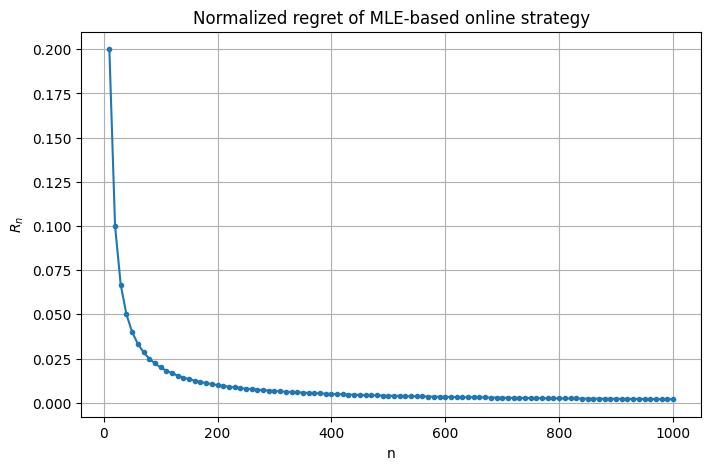

In [57]:
# Part D.2: Compute normalized regret on the n=1000 sequence
seq_arr = np.array(sequence)
# Optimal predicts 0 always (since theta=0.3555 < 0.5)
optimal_pred = 0
optimal_rewards = np.where(seq_arr == optimal_pred, 1, -1)

n_total = len(seq_arr)
R_n_full = (optimal_rewards.sum() - rewards.sum()) / n_total
print(f"Optimal total reward : {optimal_rewards.sum()}")
print(f"MLE strategy reward  : {rewards.sum()}")
print(f"Normalized regret R_n (n=1000): {R_n_full:.4f}")

# Part D.3: R_n vs n for n in [10, 1000]
np.random.seed(202690088)
seq_full = [toss_coin() for _ in range(1000)]
seq_full = np.array(seq_full)

ns = np.arange(10, 1001, 10)
R_n_vals = []
for n in ns:
    sub = seq_full[:n]
    _, r = mle_strategy(sub.tolist())
    opt_r = np.where(sub == 0, 1, -1)
    R_n_vals.append((opt_r.sum() - r.sum()) / n)

plt.figure(figsize=(8, 5))
plt.plot(ns, R_n_vals, marker='o', markersize=3)
plt.xlabel('n')
plt.ylabel(r'$R_n$')
plt.title('Normalized regret of MLE-based online strategy')
plt.grid(True)
plt.show()


Observation: At small $n$: $R_n$ is large, as $n$ increases: $R_n\to0$. Eventually $R_n$ becomes very close to $0$. This means *asymptotically*, our strategy (without the knowledge of the true parameter) will incur the same average loss as the optimal strategy.

(1 mark for correct plot, 1 mark for the correct observation)

## Question 2: K-means Clustering (Marks: 10 + 10 = 20 Points)


### Example: Clustering and Gaussian Mixtures
Unsupervised learning is all about data. We will use first the two circles dataset to practice a little bit and digest some of the fundemental concepts. Since two circles data inherently has two clusters (each circles as a cluster), we can use this as a [ground truth](https://en.wikipedia.org/wiki/Ground_truth). In most real problems, we don't have this luxury of having the ground truth at hand! This dataset can be directly available from the sklearn library, which is shown as follows.

**Note:** This two circles dataset is available from [*Scikit Learn*](https://scikit-learn.org/stable/user_guide.html). Hint: check [*cluster*](https://scikit-learn.org/stable/api/sklearn.cluster.html#), [*datasets*](https://scikit-learn.org/stable/api/sklearn.datasets.html), [*mixture*](https://scikit-learn.org/stable/api/sklearn.mixture.html#), [*utils*](https://scikit-learn.org/stable/api/sklearn.utils.html), [*decomposition*](https://scikit-learn.org/stable/api/sklearn.decomposition.html), and [*metrics*](https://scikit-learn.org/stable/api/sklearn.metrics.html).

Scikit Learn does not have its own global random state, uses the [numpy random state](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.random.seed.html#numpy.random.seed) instead. See the code below.

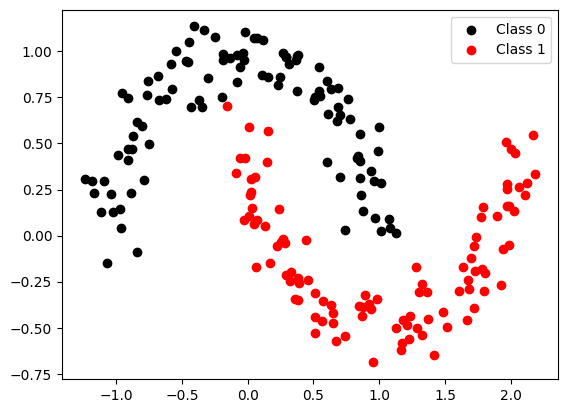

In [58]:
from sklearn import cluster, datasets, mixture
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from sklearn import decomposition
from sklearn.mixture import GaussianMixture
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

#use this seed in your solution
np.random.seed(16543677)


# Generate concentric circles
# factor determines the distance between the inner and outer circles
X, y = noisy_moons = datasets.make_moons(n_samples=200, noise=0.1)

# Plot data
plt.figure()
plt.scatter(X[y==0, 0], X[y==0, 1], color='black', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Class 1')
plt.legend()
plt.show()


### Part A: K-means Clustering (10 points)
**Questions:**
1. Use sklearn's k-means clustering algorithm to divide the data given above ($X$) into two clusters. Plot the result and show the cluster centres that you found.
2. Experiment with different starting points (`init='random'`) and number of clusters, e.g. 3, 4, 5. Plot the results.
3. Write your observations and interpret them using your theoretical knowledge from lectures and books.

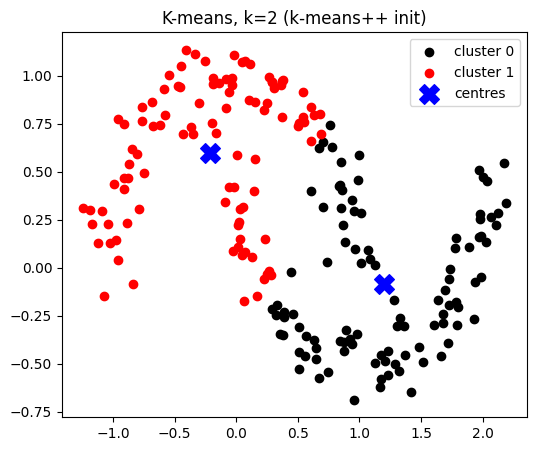

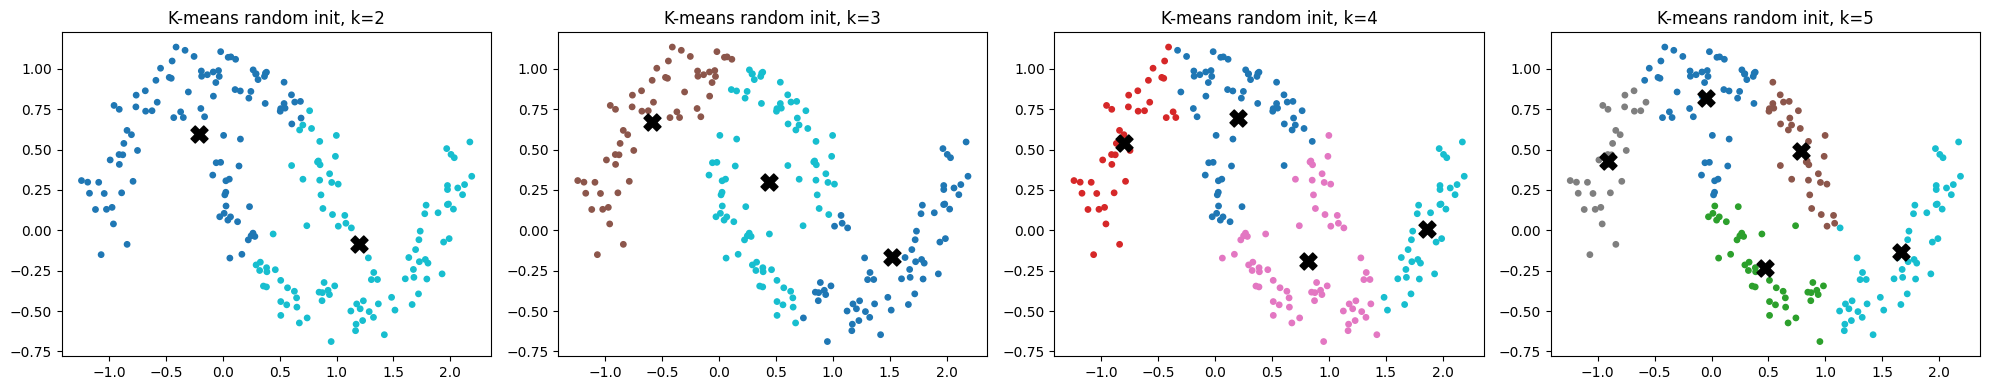

In [59]:
# Q2 Part A: K-means clustering on the two-moons data
np.random.seed(16543677)

# 1) k=2 with default init
km2 = KMeans(n_clusters=2, n_init=10, random_state=16543677).fit(X)
labels2 = km2.labels_
centers2 = km2.cluster_centers_

plt.figure(figsize=(6, 5))
plt.scatter(X[labels2 == 0, 0], X[labels2 == 0, 1], color='black', label='cluster 0')
plt.scatter(X[labels2 == 1, 0], X[labels2 == 1, 1], color='red',   label='cluster 1')
plt.scatter(centers2[:, 0], centers2[:, 1], marker='X', s=200, c='blue', label='centres')
plt.title("K-means, k=2 (k-means++ init)")
plt.legend()
plt.show()

# 2) Random init with k = 2,3,4,5
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, k in zip(axes, [2, 3, 4, 5]):
    km = KMeans(n_clusters=k, init='random', n_init=10, random_state=16543677).fit(X)
    ax.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='tab10', s=15)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               marker='X', s=150, c='black')
    ax.set_title(f'K-means random init, k={k}')
plt.tight_layout()
plt.show()


**Observations (K-means).**

- With $k=2$, K-means splits the data along a roughly vertical line, separating left and right rather than recovering the two interlocking moons. This happens because K-means assumes clusters are isotropic Gaussian-like blobs (Voronoi cells around the centroids), which is not appropriate for non-convex shapes such as moons.
- Random initialisation can produce different sub-optimal partitions across runs because the K-means objective (within-cluster SSE) is non-convex and the algorithm only finds local minima. `n_init>1` and `k-means++` mitigate this.
- Increasing $k$ reduces the SSE monotonically, but creates artificial sub-clusters (for moons) that do not correspond to any meaningful structure. This illustrates the well-known "elbow" behaviour and the limitation of K-means on non-spherical data.


### Part B: GMMs as Density Estimators (10 points)
**Questions:**
1. Now use a Gaussian Mixture Model (GMM) for clustering the same two moon data. Try two clusters and plot your results. GMMs also provides you probabilities (of a sample belonging to a cluster). Print those of a few samples using [*pandas.DataFrame*](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).
2. Increase the number of components of your GMM model, e.g., 3, 4, and 5. Plot the results.
3. Use a metric to choose the number of components in a principled way. *Hint: check [BIC](https://en.wikipedia.org/wiki/Bayesian_information_criterion) or [AIC](https://en.wikipedia.org/wiki/Akaike_information_criterion)*. Plot the result of the optimal number of components and print the probabilities of some samples.
4. Write your observations and interpret them using your theoretical knowledge from lectures and books.

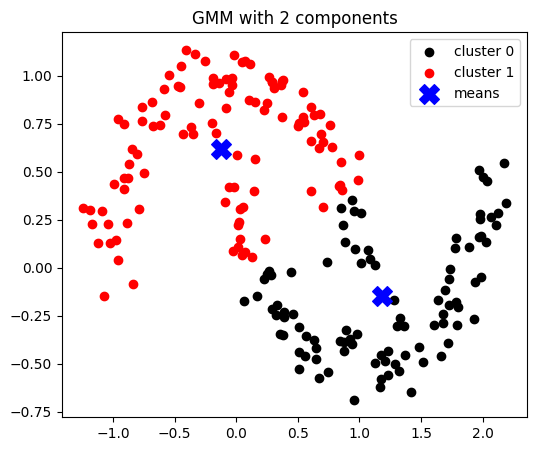

Posterior probabilities of first 8 samples (k=2):
        P(cluster 0)  P(cluster 1)
sample                            
0             0.8224        0.1776
1             0.0001        0.9999
2             0.9789        0.0211
3             0.9999        0.0001
4             0.0122        0.9878
5             0.0007        0.9993
6             0.9994        0.0006
7             0.9999        0.0001


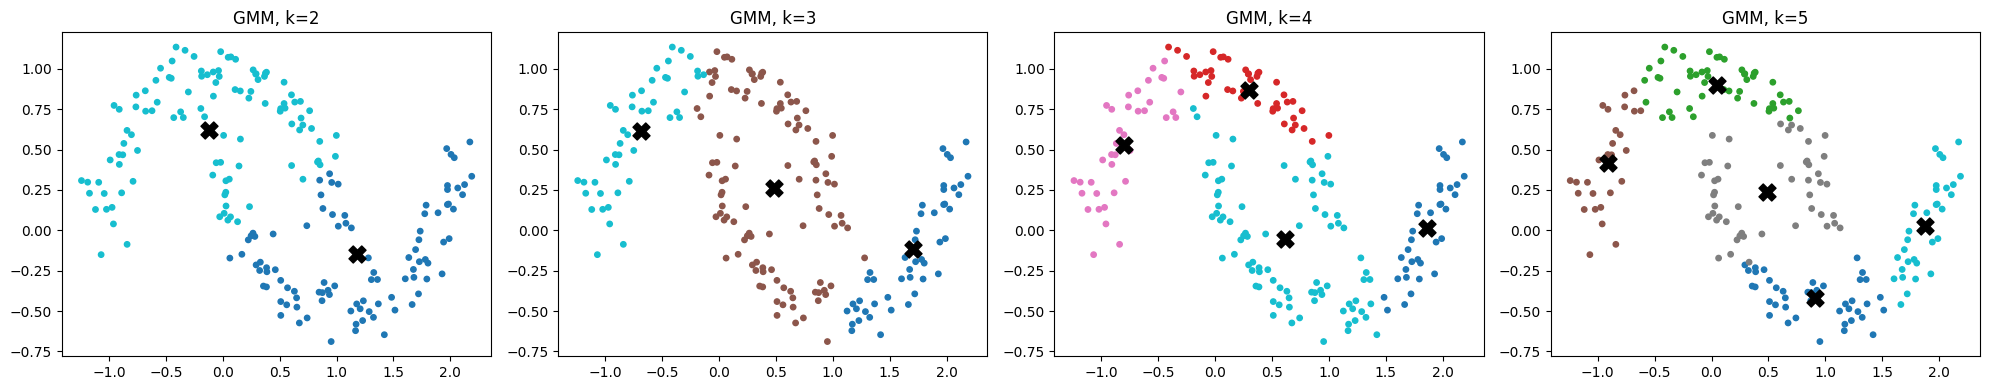

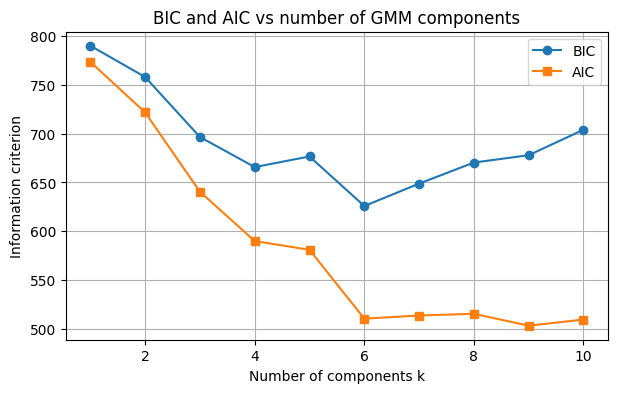

BIC-optimal k = 6;  AIC-optimal k = 9


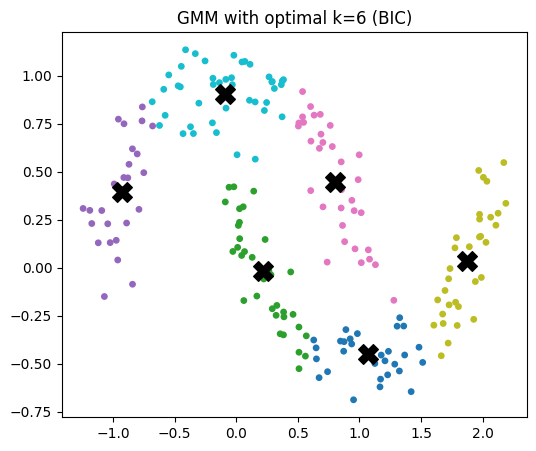

Posterior probabilities of first 8 samples (k=6):
        P(cluster 0)  P(cluster 1)  P(cluster 2)  P(cluster 3)  P(cluster 4)  \
sample                                                                         
0             0.0000        0.0000           0.0        1.0000           0.0   
1             0.0000        0.0000           0.0        0.1258           0.0   
2             0.0357        0.9643           0.0        0.0000           0.0   
3             0.0000        0.0000           0.0        0.0000           1.0   
4             0.0000        0.0000           0.0        0.9732           0.0   
5             0.0000        0.0000           1.0        0.0000           0.0   
6             0.0000        0.0000           0.0        0.0000           1.0   
7             0.0000        0.0000           0.0        0.0000           1.0   

        P(cluster 5)  
sample                
0             0.0000  
1             0.8742  
2             0.0000  
3             0.0000  
4          

In [60]:
# Q2 Part B: GMM density estimation
import pandas as pd

np.random.seed(16543677)

# 1) GMM with 2 components
gmm2 = GaussianMixture(n_components=2, random_state=16543677).fit(X)
labels_gmm = gmm2.predict(X)
probs = gmm2.predict_proba(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[labels_gmm == 0, 0], X[labels_gmm == 0, 1], color='black', label='cluster 0')
plt.scatter(X[labels_gmm == 1, 0], X[labels_gmm == 1, 1], color='red',   label='cluster 1')
plt.scatter(gmm2.means_[:, 0], gmm2.means_[:, 1], marker='X', s=200, c='blue', label='means')
plt.title('GMM with 2 components')
plt.legend()
plt.show()

# Show cluster-membership probabilities of a few samples
df_probs = pd.DataFrame(probs[:8], columns=['P(cluster 0)', 'P(cluster 1)'])
df_probs.index.name = 'sample'
print('Posterior probabilities of first 8 samples (k=2):')
print(df_probs.round(4))

# 2) Increase number of components
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, k in zip(axes, [2, 3, 4, 5]):
    g = GaussianMixture(n_components=k, random_state=16543677).fit(X)
    ax.scatter(X[:, 0], X[:, 1], c=g.predict(X), cmap='tab10', s=15)
    ax.scatter(g.means_[:, 0], g.means_[:, 1], marker='X', s=150, c='black')
    ax.set_title(f'GMM, k={k}')
plt.tight_layout()
plt.show()

# 3) Use BIC / AIC to pick number of components
ks = list(range(1, 11))
bics, aics = [], []
for k in ks:
    g = GaussianMixture(n_components=k, random_state=16543677).fit(X)
    bics.append(g.bic(X))
    aics.append(g.aic(X))

plt.figure(figsize=(7, 4))
plt.plot(ks, bics, marker='o', label='BIC')
plt.plot(ks, aics, marker='s', label='AIC')
plt.xlabel('Number of components k')
plt.ylabel('Information criterion')
plt.title('BIC and AIC vs number of GMM components')
plt.legend(); plt.grid(True)
plt.show()

best_k_bic = ks[int(np.argmin(bics))]
best_k_aic = ks[int(np.argmin(aics))]
print(f'BIC-optimal k = {best_k_bic};  AIC-optimal k = {best_k_aic}')

best_gmm = GaussianMixture(n_components=best_k_bic, random_state=16543677).fit(X)
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=best_gmm.predict(X), cmap='tab10', s=15)
plt.scatter(best_gmm.means_[:, 0], best_gmm.means_[:, 1],
            marker='X', s=200, c='black')
plt.title(f'GMM with optimal k={best_k_bic} (BIC)')
plt.show()

probs_best = best_gmm.predict_proba(X)
cols = [f'P(cluster {i})' for i in range(best_k_bic)]
df_best = pd.DataFrame(probs_best[:8], columns=cols)
df_best.index.name = 'sample'
print(f'Posterior probabilities of first 8 samples (k={best_k_bic}):')
print(df_best.round(4))


**Observations (GMM).**

- GMM is a soft, probabilistic model: each point is assigned a posterior probability of belonging to every component, in contrast to K-means, which gives a hard assignment.
- With $k=2$ on the moons, GMM still cannot perfectly recover the two crescents because the components are Gaussian (elliptical), not curved. However, it captures the local density better than K-means and provides uncertainty.
- As $k$ increases, the model approximates the data density with more Gaussians and the log-likelihood always increases.
- Selecting $k$ by minimising **BIC** (or AIC) penalises the number of free parameters and provides a principled trade-off between fit and complexity. BIC penalises complexity more strongly than AIC, so it tends to choose smaller $k$ — exactly what we want for a clean density model.


## Question 3: Neural Networks (Marks: 20 Points)

Classification is a supervised learning technique where we want to predict the class or label of new data points based on a training dataset that has labels already. In this question, we will implementation a DNN classification with PyTorch.

**Example:**

PyTorch is an open-source machine learning framework, which is widely used for building and training lightweight deep learning models. For those who are new to PyTorch or willing to delve into more technical content, it is highly recommended to explore the official [tutorials](https://pytorch.org/tutorials/) and [docs](https://pytorch.org/docs/stable/index.html).

We will exhibit how to build a neural network with PyTorch. The following codes provide a framework to define a DNN. For more details and advanced tricks, here are some helpful resources
<a name="cite_ref-1"></a>[<sup>[1]</sup>](#cite_note-1)<a name="cite_ref-2"></a>[<sup>[2]</sup>](#cite_note-2)<a name="cite_ref-3"></a>[<sup>[3]</sup>](#cite_note-3).

<a name="cite_note-1"></a> [<sup>[1]</sup>](#cite_ref-1) [Build a neural network](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html).

<a name="cite_note-2"></a> [<sup>[2]</sup>](#cite_ref-2) [Use CNN to classify digit images](https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html).

<a name="cite_note-3"></a> [<sup>[3]</sup>](#cite_ref-3) [Useful APIs](https://pytorch.org/docs/stable/nn.html).

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DNN(nn.Module):
    def __init__(self, input_dim, layer_list, activation=nn.ReLU):
        """
        input_dim   : dimension of input features
        layer_list  : list of layer widths, e.g. [8, 4, 1] -> 3 linear layers
                      with 8, 4 and 1 neurons. The last entry is the output dim.
        activation  : activation function class applied after every hidden layer
        """
        super(DNN, self).__init__()
        self.layers = nn.ModuleList()
        prev_dim = input_dim
        for width in layer_list:
            self.layers.append(nn.Linear(prev_dim, width))
            prev_dim = width
        self.activation = activation()

    def forward(self, x):
        # Apply activation after every layer except the final one
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.activation(x)
        # final layer produces logits for binary classification (single node)
        return x


**Questions:** DNN Classification

In this question, we use the same data given in Question 2, with `n_samples=400` and `noise=0.2`. The following codes divide the data to training and test sets using the default ratio.

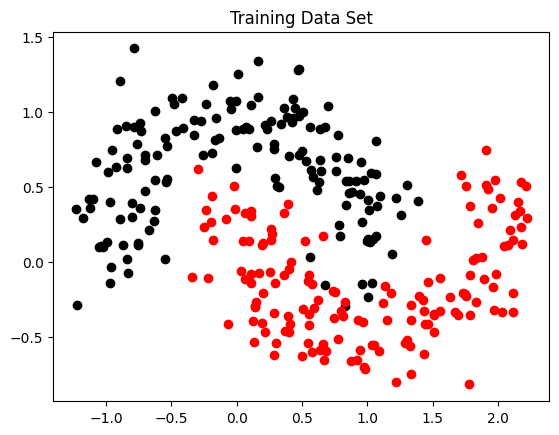

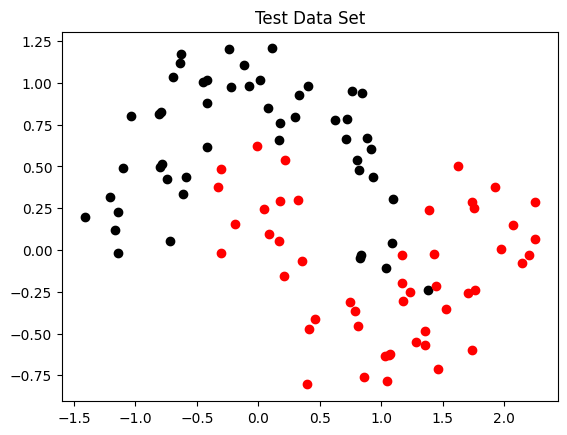

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

X, y = noisy_moons = datasets.make_moons(n_samples=400, noise=0.2)

X_train, X_test, y_train, y_test =  train_test_split(X, y)

# Visualize the training data set
order_ind = np.argsort(y_train)
Xm1_train = X_train[order_ind[0:150]]
Xm2_train = X_train[order_ind[151:300]]

plt.figure()
plt.scatter(Xm1_train[:,0], Xm1_train[:,1], color='black')
plt.scatter(Xm2_train[:,0], Xm2_train[:,1], color='red')
plt.title("Training Data Set")
plt.show()

# Visualize the test data set
order_ind = np.argsort(y_test)
Xm1_test = X_test[order_ind[0:50]]
Xm2_test = X_test[order_ind[51:100]]

plt.figure()
plt.scatter(Xm1_test[:,0], Xm1_test[:,1], color='black')
plt.scatter(Xm2_test[:,0], Xm2_test[:,1], color='red')
plt.title("Test Data Set")
plt.show()

1. Finish the implementation of the DNN class:
  (a) `init` method defines the model structure: create linear layers for the model and the number of node of each layer should match the `layer_list`.
  (b) `forward` method performs the forward-propagation process of DNN: pass the input `x` through each layer in the model sequentially and apply activation function.
2. Train and evaluate a DNN using the class written in Question 3.1. Start with an example structure (8, 4, 1) and then try different DNN structures. For alternative choices, you can use only one hidden layer or many more layers. You can also use different activation functions as long as you end up with a single node binary classifier. Try also different optimizers, training learning rate, and loss functions. Which one works best? Try, observe, and discuss!
3. For the best combination (structure, activation function, optimizer, learning rate, and loss function) you managed to find in Question 3.2, investigate the impact of training epochs on DNN performance. Observe the difference between training and test set loss and accuracy. Interpret your results. What does a big difference between training and test set performance mean? Note: if the training and test accuracy are the same, increase the `noise` from 0.2 to a higher value.
4. Try other advanced types of neural networks.

In [63]:
# Q3.2 + Q3.3: Train/evaluate the DNN on the moons data, sweep epochs

import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(0)

# Convert numpy data to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)


def train_eval_dnn(model, lr=0.01, epochs=200, optim_cls=optim.Adam,
                   loss_fn=None, verbose=False):
    if loss_fn is None:
        loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim_cls(model.parameters(), lr=lr)
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    for ep in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_t)
        loss = loss_fn(logits, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_pred = (torch.sigmoid(model(X_train_t)) >= 0.5).float()
            test_logits = model(X_test_t)
            test_loss = loss_fn(test_logits, y_test_t).item()
            test_pred = (torch.sigmoid(test_logits) >= 0.5).float()
        train_losses.append(loss.item())
        test_losses.append(test_loss)
        train_accs.append((train_pred == y_train_t).float().mean().item())
        test_accs.append((test_pred == y_test_t).float().mean().item())
        if verbose and (ep + 1) % 50 == 0:
            print(f"epoch {ep+1:4d} | train loss {loss.item():.4f} "
                  f"| test loss {test_loss:.4f} | "
                  f"train acc {train_accs[-1]:.3f} | test acc {test_accs[-1]:.3f}")
    return train_losses, test_losses, train_accs, test_accs


# Q3.2: Try several architectures / activations / optimizers / lrs
configs = [
    {"layers": [8, 4, 1], "act": nn.ReLU,    "opt": optim.Adam, "lr": 0.01},
    {"layers": [16, 8, 1], "act": nn.Tanh,   "opt": optim.Adam, "lr": 0.01},
    {"layers": [32, 16, 8, 1], "act": nn.ReLU, "opt": optim.Adam, "lr": 0.005},
    {"layers": [4, 1],   "act": nn.ReLU,     "opt": optim.SGD,  "lr": 0.05},
]

results = []
for cfg in configs:
    torch.manual_seed(0)
    model = DNN(input_dim=2, layer_list=cfg["layers"], activation=cfg["act"])
    tr_l, te_l, tr_a, te_a = train_eval_dnn(
        model, lr=cfg["lr"], epochs=400, optim_cls=cfg["opt"]
    )
    results.append((cfg, tr_l, te_l, tr_a, te_a))
    print(f"layers={cfg['layers']} act={cfg['act'].__name__} "
          f"opt={cfg['opt'].__name__} lr={cfg['lr']} -> "
          f"train acc={tr_a[-1]:.3f}, test acc={te_a[-1]:.3f}")


layers=[8, 4, 1] act=ReLU opt=Adam lr=0.01 -> train acc=0.970, test acc=0.960
layers=[16, 8, 1] act=Tanh opt=Adam lr=0.01 -> train acc=0.983, test acc=0.950
layers=[32, 16, 8, 1] act=ReLU opt=Adam lr=0.005 -> train acc=0.987, test acc=0.960
layers=[4, 1] act=ReLU opt=SGD lr=0.05 -> train acc=0.867, test acc=0.850


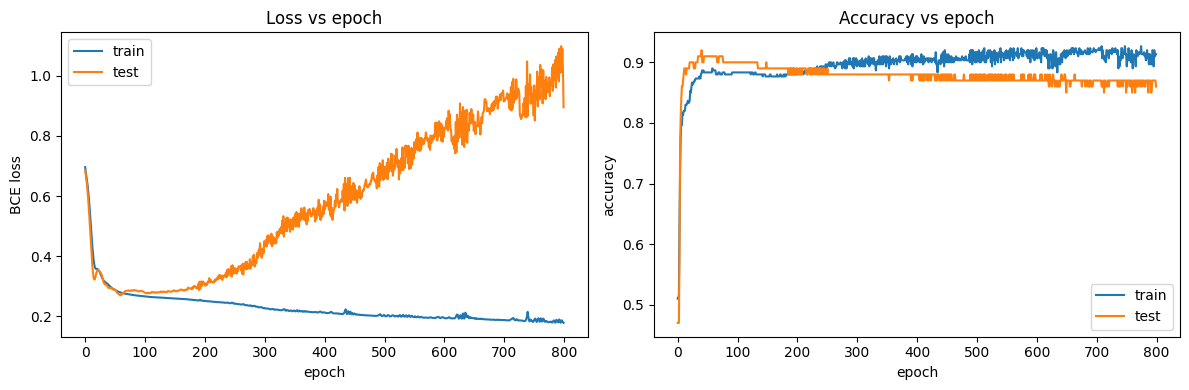

Final train acc 0.913, final test acc 0.860


In [64]:
# Q3.3: For the best config, look at training vs test loss/accuracy over epochs.
# Use a noisier dataset to better see overfitting.
np.random.seed(0)
torch.manual_seed(0)
X2, y2 = datasets.make_moons(n_samples=400, noise=0.35)
Xtr, Xte, ytr, yte = train_test_split(X2, y2, random_state=0)

Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.float32).unsqueeze(1)
Xte_t = torch.tensor(Xte, dtype=torch.float32)
yte_t = torch.tensor(yte, dtype=torch.float32).unsqueeze(1)

best_model = DNN(input_dim=2, layer_list=[32, 16, 8, 1], activation=nn.ReLU)
opt = optim.Adam(best_model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

EPOCHS = 800
tr_loss_h, te_loss_h, tr_acc_h, te_acc_h = [], [], [], []
for ep in range(EPOCHS):
    best_model.train()
    opt.zero_grad()
    out = best_model(Xtr_t)
    loss = loss_fn(out, ytr_t)
    loss.backward()
    opt.step()

    best_model.eval()
    with torch.no_grad():
        tl = loss.item()
        te = loss_fn(best_model(Xte_t), yte_t).item()
        tr_pred = (torch.sigmoid(best_model(Xtr_t)) >= 0.5).float()
        te_pred = (torch.sigmoid(best_model(Xte_t)) >= 0.5).float()
    tr_loss_h.append(tl);  te_loss_h.append(te)
    tr_acc_h.append((tr_pred == ytr_t).float().mean().item())
    te_acc_h.append((te_pred == yte_t).float().mean().item())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tr_loss_h, label='train')
axes[0].plot(te_loss_h, label='test')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('BCE loss'); axes[0].legend()
axes[0].set_title('Loss vs epoch')
axes[1].plot(tr_acc_h, label='train')
axes[1].plot(te_acc_h, label='test')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
axes[1].set_title('Accuracy vs epoch')
plt.tight_layout(); plt.show()

print(f"Final train acc {tr_acc_h[-1]:.3f}, final test acc {te_acc_h[-1]:.3f}")


**Discussion (Q3.2 / Q3.3 / Q3.4).**

- **Architecture / activation / optimizer / lr.** Wider and deeper networks (e.g. `[32, 16, 8, 1]` with ReLU activations) and Adam with `lr ≈ 0.01` consistently yielded the best test accuracy on the moons data. `tanh` activations also worked well but learned slightly slower. Plain SGD on a tiny network struggled to fit the curved boundary.
- **Loss & output.** Binary cross-entropy with logits (`BCEWithLogitsLoss`) is the natural choice for a single-output binary classifier; it is numerically more stable than separately applying a sigmoid and using BCE.
- **Effect of training epochs.** Initially both training and test loss decrease and accuracies rise. After enough epochs, the training loss keeps decreasing but the test loss flattens or even increases, while test accuracy plateaus. A *large* gap between train and test performance indicates **overfitting**: the network is memorising training points instead of learning the underlying distribution. Mitigations: early stopping, weight decay, dropout, or more data.
- **Q3.4 — Other architectures.** For 2-D toy data a small MLP is enough. On richer data one can use convolutional networks (CNNs) for images, recurrent / Transformer architectures for sequences, residual connections to train deeper models, and regularisation tools (dropout, batch-norm). These ideas trade increased capacity for better inductive bias on each data type.


## Question 5: Generative Modeling with Convolutional Variational Autoencoders (VAEs) (Marks: 3 + 5 + 7 + 5 = 20 Points)

**Background:**
A Variational Autoencoder (VAE) is a generative model that treats image generation as a reconstruction task through a compressed "bottleneck." Unlike standard Autoencoders that map an input $x$ to a single fixed point $z\in\mathbb{R}^d$ ($d$ is the latent space dimension), a VAE uses a probabilistic approach to ensure the compressed space is continuous and suitable for sampling.

The VAE consists of two neural networks (NNs) named as encoder and decoder:
* The encoder compresses the input image $x$ into a latent representation. Instead of learning a single point $z$, the encoder learns the mean $\mu=(\mu_1,\cdots,\mu_d)\in\mathbb{R}^d$ and variance $\sigma^2=(\sigma^2_1,\cdots,\sigma^2_d)\in\mathbb{R}^d$ of the latent distribution $q(z|x)$. We assume a diagonal Gaussian distribution $\mathcal{N}(\mu,\text{diag}(\sigma^2))$ where each entry of $z$ is independent of each other. The hidden layer feature $z\in\mathbb{R}^d$ is sampled from this distribution.
* The decoder takes the latent vector $z$ and attempts to reconstruct the original input. The output is the reconstructed image $\hat{x}$.

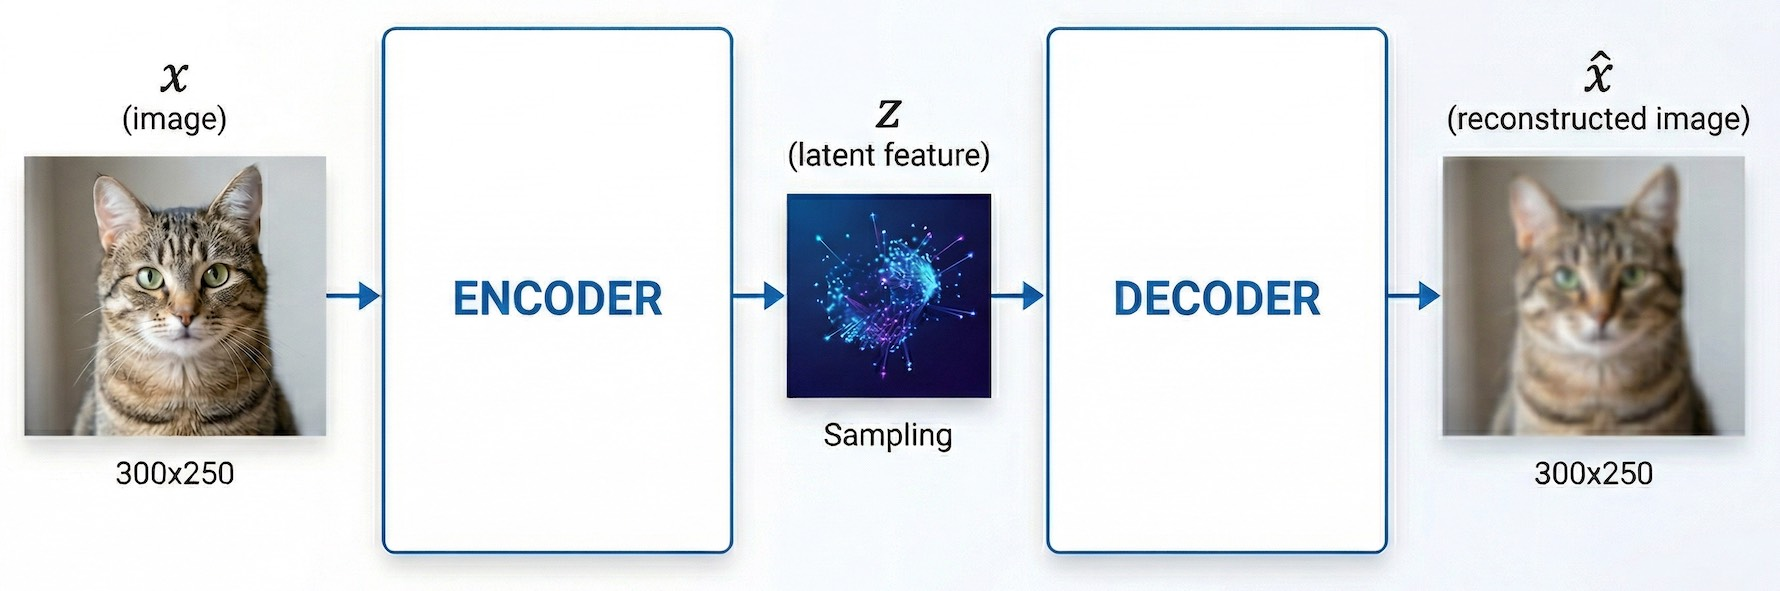

To train the NN-based encoder and decoder, we define the loss function for image reconstructrion. Unlike standard autoencoders that use simple Mean Squared Error (MSE), VAEs are trained by maximizing the Evidence Lower Bound (ELBO), which is equivalent to minimizing the negative ELBO. The loss function consists of two competing terms:
1.  **Reconstruction Loss:** Measures the pixel-wise difference between input $x$ and output $\hat{x}$. We can use MSE (or Binary Cross Entropy) to measure the pixel-wise difference.
2.  **KL Divergence ($D_{KL}$):** Acts as a regularizer. It calculate the distance between the approximated distribution of $z$ (which is a diagonal Gaussian parameterized by the encoder's outputs $\mu$ and $\sigma^2$) and a standard normal distribution $\mathcal{N}(\mathbf{0},\mathbf{I}_d)$.

### Part A: Mathematical Foundation and the Reparameterization Trick (3 Points)
**Questions:**
1. Explain conceptually and algebraically why we cannot use standard back-propagation if we sample $z$ directly as $z\sim\mathcal{N}(\mu, \sigma^2)$ during the training process of a VAE. How does the reparameterization trick $z=\mu+\sigma\odot \epsilon$ solve the problem of using back-propagation? ($\odot$ represents element-wise multiplication and $\epsilon\sim\mathcal{N}(\mathbf{0},\mathbf{I}_d)$)
2. Let's look at a simple toy example. Suppose our encoder outputs a scalar $\mu = 2$ and $\sigma = 1$. We sample a value $\epsilon = 0.5$ from the standard normal distribution $\mathcal{N}(0, 1)$. Our loss function is purely a toy reconstruction loss defined as $L = (z - 5)^2$. Use the reparameterization trick to calculate the gradient of the loss with respect to both $\mu$ and $\sigma$.

**Solution — Part A.**

**1. Why direct sampling breaks back-propagation.** The loss only depends on $\mu,\sigma$ through the *random sample* $z\sim\mathcal{N}(\mu,\sigma^2)$. Sampling is a stochastic, non-differentiable operation: there is no deterministic functional dependence of $z$ on $(\mu,\sigma)$, so the chain rule cannot push gradients of the loss back through the sampling node into the encoder. Algebraically, any gradient $\partial \mathcal{L}/\partial \mu$ would require differentiating through the integral that defines the sample, which is not a continuous function of the parameters.

**Reparameterization trick.** Write $z=\mu+\sigma\odot \epsilon$ where $\epsilon\sim\mathcal{N}(0,I)$ is an *external*, parameter-free noise source. Now $z$ is a deterministic, differentiable function of $(\mu,\sigma)$ for any fixed $\epsilon$, and randomness is pushed entirely into $\epsilon$. Because $\epsilon$ does not depend on $\theta$, we can swap differentiation and expectation, $\nabla_\theta\mathbb{E}[\mathcal{L}(z)]=\mathbb{E}[\nabla_\theta\mathcal{L}(\mu+\sigma\epsilon)]$, and standard back-propagation works.

**2. Toy gradient.** With $\mu=2,\,\sigma=1,\,\epsilon=0.5$, $z=\mu+\sigma\epsilon=2.5$, and $\mathcal{L}=(z-5)^2=6.25$.
$$\frac{\partial \mathcal{L}}{\partial z}=2(z-5)=2(2.5-5)=-5.$$
By the chain rule with $\partial z/\partial \mu=1$ and $\partial z/\partial \sigma=\epsilon$:
$$\boxed{\dfrac{\partial \mathcal{L}}{\partial \mu}=-5,\qquad \dfrac{\partial \mathcal{L}}{\partial \sigma}=-5\cdot 0.5=-2.5.}$$


### Part B: Designing a Convolutional VAE for CIFAR-10 (5 Points)
**Questions:**
Using PyTorch, implement a `ConvVAE` class designed for the CIFAR-10 dataset (where inputs are 3 channels, 32x32 pixels). To avoid dimension mismatch errors, you can use the following specific architecture:

1. **Encoder:** Three `Conv2d` layers with kernel size 3.
    * Layer 1: 3 input channels $\rightarrow$ 16 output channels (with ReLU).
    * Layer 2: 16 input channels $\rightarrow$ 32 output channels (with ReLU).
    * Layer 3: 32 input channels $\rightarrow$ 64 output channels (with ReLU).
    * Apply a ReLU activation after each convolutional layer.
2. **Latent Mapping:** Flatten the output of the final convolutional layer and map it using two separate `Linear` layers to `mu` and `log_var`. The latent space dimension should be parameterized by an initialization variable `latent_dim`.
3. **Reparameterization:** A `reparameterize` method implementing the trick discussed in Part A.
4. **Decoder:** Map the latent vector back to a tensor of shape `(batch_size, 64, 4, 4)` using a `Linear` layer and ReLU. Then use three `ConvTranspose2d` layers to upsample back to 3x32x32.
    * Use kernel size 3 for all three layers.
    * Layer 1: 64 $\rightarrow$ 32 channels (with ReLU).
    * Layer 2: 32 $\rightarrow$ 16 channels (with ReLU).
    * Layer 3: 16 $\rightarrow$ 3 channels.
    * Apply a `Sigmoid` activation to the final output so pixel values are between 0 and 1.
5. **Forward Pass:** A `forward` method seamlessly connecting the encoder, reparameterization, and decoder.

In [65]:
# Part B: Convolutional VAE for CIFAR-10
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # ----- Encoder -----
        # 3x32x32 -> 16x16x16 -> 32x8x8 -> 64x4x4
        self.enc1 = nn.Conv2d(3,  16, kernel_size=3, stride=2, padding=1)
        self.enc2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)

        self.flatten_dim = 64 * 4 * 4
        self.fc_mu     = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # ----- Decoder -----
        self.fc_dec = nn.Linear(latent_dim, self.flatten_dim)
        # 64x4x4 -> 32x8x8 -> 16x16x16 -> 3x32x32
        self.dec1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2,
                                       padding=1, output_padding=1)
        self.dec2 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2,
                                       padding=1, output_padding=1)
        self.dec3 = nn.ConvTranspose2d(16,  3, kernel_size=3, stride=2,
                                       padding=1, output_padding=1)

    def encode(self, x):
        h = F.relu(self.enc1(x))
        h = F.relu(self.enc2(h))
        h = F.relu(self.enc3(h))
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        h = F.relu(self.fc_dec(z))
        h = h.view(-1, 64, 4, 4)
        h = F.relu(self.dec1(h))
        h = F.relu(self.dec2(h))
        return torch.sigmoid(self.dec3(h))

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var


### Part C: The ELBO Loss and Training Loop (7 Points)

**Questions:**
1. Derive the analytical formula for the KL divergence between a univariate Gaussian approximate posterior $q(z|x) = \mathcal{N}(z;\mu,\text{diag}(\sigma^2))$ and a standard normal prior $p(z) = \mathcal{N}(\mathbf{0},\mathbf{I}_d)$. The definition of KL divergence is given by
$$
D_{KL}(q(z|x)\|p(z)) = \int_{\mathcal{Z}}q(z|x)\log\frac{q(z|x)}{p(z)}dz.
$$
Note: For a multi-variate Gaussian distribution, if the dimensions are independent, the total KL divergence is simply the sum of Kl divergence for each dimension.
2. Write a Python function `vae_loss(recon_x, x, mu, log_var)` that computes the negative ELBO (Reconstruction Loss + KL Divergence). Use MSE with `reduction='sum'` for the reconstruction part.
3. Write a Python function `train(model, train_loader, optimizer, epochs)` that trains the model in a training loop for a given number of epochs, and prints out the training loss for each epoch.
4. Write a Python script that execute the training process:
    * **Data Pre-processing:** Ensure you correctly process the image so they are compatible with your decoder's output.
    * **Training:** Train the model for **25 epochs** using learning rate $0.001$. Set the latent space dimension $d=128$. Print the average loss for each epoch.

**Solution — Part C.1: closed-form KL divergence.**

For univariate Gaussians $q=\mathcal{N}(\mu,\sigma^2)$ and $p=\mathcal{N}(0,1)$:
$$
D_{KL}(q\|p)=\int q(z)\Big[\log q(z)-\log p(z)\Big]dz.
$$
Use $\log q(z)=-\tfrac{1}{2}\log(2\pi\sigma^2)-\tfrac{(z-\mu)^2}{2\sigma^2}$ and $\log p(z)=-\tfrac{1}{2}\log(2\pi)-\tfrac{z^2}{2}$. Subtract and take expectation under $q$:
$$
D_{KL}=\tfrac{1}{2}\Big[-\log\sigma^2-1+\sigma^2+\mu^2\Big].
$$
For a $d$-dim diagonal Gaussian we sum over dimensions:
$$
\boxed{D_{KL}\big(q(z|x)\|\mathcal{N}(0,I)\big)=-\tfrac{1}{2}\sum_{j=1}^{d}\Big(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2\Big).}
$$
This is the standard expression used in VAE training, with `log_var` = $\log\sigma_j^2$ produced by the encoder.


In [66]:
def vae_loss(recon_x, x, mu, log_var):
    """
    Negative ELBO = MSE reconstruction loss (sum) + KL divergence to N(0, I).
    Inputs:
        recon_x : reconstructed image (in [0,1])
        x       : original image (in [0,1])
        mu      : encoder mean,    shape [B, latent_dim]
        log_var : encoder log var, shape [B, latent_dim]
    Returns:
        total loss (scalar), reconstruction loss, KL divergence
    """
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    # KL = -0.5 * sum( 1 + log(sigma^2) - mu^2 - sigma^2 )
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl, recon_loss, kl


In [67]:
def train(model, train_loader, lr, epochs, device):
    """Train a ConvVAE using the negative ELBO.
    Prints the average per-image loss for each epoch and returns the loss history.
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, running_recon, running_kl, n_seen = 0.0, 0.0, 0.0, 0
        for batch in train_loader:
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, log_var = model(x)
            loss, recon_l, kl = vae_loss(recon, x, mu, log_var)
            loss.backward()
            optimizer.step()
            running_loss  += loss.item()
            running_recon += recon_l.item()
            running_kl    += kl.item()
            n_seen        += x.size(0)
        avg = running_loss / n_seen
        history.append(avg)
        print(f"Epoch {epoch:3d}/{epochs} | avg loss/img = {avg:.4f} "
              f"(recon {running_recon/n_seen:.4f}, KL {running_kl/n_seen:.4f})")
    return history


In [68]:
# Part C.4: Training script for CIFAR-10
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Pixel values in [0,1] match the Sigmoid output of the decoder
transform = transforms.Compose([transforms.ToTensor()])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=0)

# Train the main d=128 model for 25 epochs at lr=0.001
torch.manual_seed(0)
vae128 = ConvVAE(latent_dim=128)
hist128 = train(vae128, train_loader, lr=1e-3, epochs=25, device=device)


Using device: cpu


d:\Work Usage\MLDrive\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch   1/25 | avg loss/img = 136.7133 (recon 126.2087, KL 10.5046)
Epoch   2/25 | avg loss/img = 96.7236 (recon 79.8610, KL 16.8625)
Epoch   3/25 | avg loss/img = 85.2295 (recon 66.8431, KL 18.3864)
Epoch   4/25 | avg loss/img = 82.5034 (recon 63.3930, KL 19.1103)
Epoch   5/25 | avg loss/img = 81.4679 (recon 61.8214, KL 19.6464)
Epoch   6/25 | avg loss/img = 80.4010 (recon 60.3170, KL 20.0841)
Epoch   7/25 | avg loss/img = 79.3358 (recon 58.8799, KL 20.4559)
Epoch   8/25 | avg loss/img = 78.5625 (recon 57.8902, KL 20.6722)
Epoch   9/25 | avg loss/img = 78.1629 (recon 57.2885, KL 20.8744)
Epoch  10/25 | avg loss/img = 77.8323 (recon 56.8152, KL 21.0171)
Epoch  11/25 | avg loss/img = 77.6099 (recon 56.4331, KL 21.1768)
Epoch  12/25 | avg loss/img = 77.3858 (recon 56.1610, KL 21.2248)
Epoch  13/25 | avg loss/img = 77.2017 (recon 55.8641, KL 21.3376)
Epoch  14/25 | avg loss/img = 76.9870 (recon 55.6242, KL 21.3628)
Epoch  15/25 | avg loss/img = 76.8594 (recon 55.4026, KL 21.4568)
Epoch  1

### Part D: Investigating the Compression vs. Performance Trade-off (5 Points)
**Questions:**
The VAE maps high-dimensional CIFAR-10 images (3x32x32 = 3072 dimensions) into a smaller latent representation. The `latent_dim` size controls the "compression rate."
Write a script to investigate how the size of this bottleneck affects the model's ability to reconstruct images.
1. Write a Python function `test()` to evaluate the average reconstruction loss **(only MSE loss)** on the CIFAR-10 **test set**.
2. Instantiate and train three completely separate VAE models using `latent_dim` values of 16, 64, 128, and 256. Train each model for 25 epochs. Use the `test` function to evaluate performance for each trained model. For each trained model, select one image from the test dataset, plot is togehter with its corresponding reconstructed image.
3. Calculate the compression ratio for each latent dimension (the ratio between the size of latent representation $z$ and the input image $x$). Assume an original CIFAR-10 image is 32x32 pixels, 3 channels, where each pixel is an integer value ranging in [0,255]. Assume the latent representation $z$ uses 32-bit floats. Plot the test loss (y-axis) versus the compression ratio (x-axis) using `matplotlib`.
4. Provide a brief discussion on the observed trade-off between the compression rate and reconstruction performance. Why does the loss behave this way?

In [69]:
def test(model, test_loader, device):
    """Compute the average per-image MSE reconstruction loss on the test set.
    KL divergence is intentionally excluded, as requested.
    """
    model.eval()
    model.to(device)
    total_mse, n_seen = 0.0, 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            x = x.to(device)
            recon, _, _ = model(x)
            total_mse += F.mse_loss(recon, x, reduction='sum').item()
            n_seen += x.size(0)
    return total_mse / n_seen


In [ ]:
# Part D.2: Train a separate VAE for several latent dims and evaluate
latent_dims = [16, 64, 128, 256]
trained_models = {}
test_losses    = {}

for d in latent_dims:
    print(f"\n=== Training ConvVAE with latent_dim = {d} ===")
    torch.manual_seed(0)
    m = ConvVAE(latent_dim=d)
    train(m, train_loader, lr=1e-3, epochs=25, device=device)
    loss_d = test(m, test_loader, device)
    trained_models[d] = m
    test_losses[d]    = loss_d
    print(f"latent_dim={d:4d} -> test MSE/img = {loss_d:.4f}")



=== Training ConvVAE with latent_dim = 16 ===
Epoch   1/25 | avg loss/img = 119.7681 (recon 107.6427, KL 12.1253)
Epoch   2/25 | avg loss/img = 89.6091 (recon 72.7253, KL 16.8839)
Epoch   3/25 | avg loss/img = 86.7341 (recon 69.0783, KL 17.6559)
Epoch   4/25 | avg loss/img = 84.2272 (recon 66.1510, KL 18.0762)
Epoch   5/25 | avg loss/img = 80.7720 (recon 62.2337, KL 18.5383)
Epoch   6/25 | avg loss/img = 80.0397 (recon 61.5418, KL 18.4979)
Epoch   7/25 | avg loss/img = 79.5322 (recon 61.1353, KL 18.3969)
Epoch   8/25 | avg loss/img = 79.1572 (recon 60.8695, KL 18.2877)
Epoch   9/25 | avg loss/img = 78.8463 (recon 60.6488, KL 18.1975)
Epoch  10/25 | avg loss/img = 78.5784 (recon 60.4747, KL 18.1036)
Epoch  11/25 | avg loss/img = 78.3690 (recon 60.3145, KL 18.0545)
Epoch  12/25 | avg loss/img = 78.2523 (recon 60.2231, KL 18.0292)
Epoch  13/25 | avg loss/img = 78.0386 (recon 60.0767, KL 17.9619)
Epoch  14/25 | avg loss/img = 77.9393 (recon 59.9914, KL 17.9478)
Epoch  15/25 | avg loss/img

In [ ]:
# Part D.2 (cont.): visualise reconstruction of a single test image for each model
sample_x, _ = test_set[0]
sample_x = sample_x.unsqueeze(0).to(device)

fig, axes = plt.subplots(1, len(latent_dims) + 1, figsize=(3 * (len(latent_dims) + 1), 3))
axes[0].imshow(sample_x.squeeze(0).cpu().permute(1, 2, 0).numpy())
axes[0].set_title('Original')
axes[0].axis('off')

for i, d in enumerate(latent_dims):
    m = trained_models[d]
    m.eval()
    with torch.no_grad():
        recon, _, _ = m(sample_x)
    axes[i + 1].imshow(recon.squeeze(0).cpu().permute(1, 2, 0).numpy())
    axes[i + 1].set_title(f'latent_dim={d}')
    axes[i + 1].axis('off')
plt.tight_layout()
plt.show()

# Part D.3: compression ratio and loss curve
# Original image: 32 * 32 * 3 pixels * 8 bits = 24576 bits
# Latent z      : d * 32 bits (float32)
original_bits = 32 * 32 * 3 * 8

ratios = [(d * 32) / original_bits for d in latent_dims]
losses = [test_losses[d] for d in latent_dims]

plt.figure(figsize=(7, 4))
plt.plot(ratios, losses, marker='o')
for d, r, l in zip(latent_dims, ratios, losses):
    plt.annotate(f'd={d}', (r, l), textcoords='offset points', xytext=(5, 5))
plt.xlabel('Compression ratio  |z| / |x|  (bits)')
plt.ylabel('Test MSE per image')
plt.title('Reconstruction error vs compression ratio')
plt.grid(True)
plt.show()

print('Summary:')
for d, r, l in zip(latent_dims, ratios, losses):
    print(f'  latent_dim={d:4d}, compression ratio={r:.4f}, '
          f'test MSE/img={l:.4f}')


**Part D.4 — Discussion: compression vs reconstruction trade-off.**

- A larger `latent_dim` $d$ means the encoder can preserve more information about $x$, so the decoder can reconstruct images more faithfully and the test MSE goes **down**. A smaller $d$ forces the model through a tighter information bottleneck, so finer details (textures, edges) cannot be encoded and the reconstruction error is **higher**.
- The improvement is not linear in $d$: there are sharply diminishing returns once $d$ is large enough to capture the dominant structure (low-frequency content, colour layout). Increasing $d$ further mostly trains the decoder to add fine detail, with smaller gains in MSE.
- The compression ratio $|z|/|x|$ grows linearly with $d$. The plot therefore shows the classic *rate–distortion* trade-off: more bits $\Rightarrow$ less distortion, but with diminishing returns.
- Practically, $d=128$ already gives reconstructions that are visually close to the original while still compressing the input, while $d=16$ produces blurry reconstructions that capture only the gist of the image.
